# 1 Basic Matrix/Vector Manipulation (20 points)

In [16]:
# (a) Define Matrix M and Vectors a,b,c in Python using Numpy.
import numpy as np

M = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9], [0, 2, 2]])
a = np.array([[1], [1], [0]])
b = np.array([[-1], [2], [5]])
c = np.array([[0], [2], [3], [2]])

In [17]:
# (b) Find the dot product of vectors a and b (i.e. a⊤b).
np.dot(np.transpose(a), b)

array([[1]])

In [18]:
# (c) Find the element-wise product of a and b [a1b1,a2b2,a3b3]T .
np.multiply(a, b)

array([[-1],
       [ 2],
       [ 0]])

In [19]:
# (d) Find (a⊤b)Ma.
# Answer: Can't be computed because the dimensions of a⊤b and M do not match.
# a⊤b is a 1x1 matrix, while M is a 4x3 matrix.
# Therefore, the multiplication (a⊤b)M is not defined.

In [20]:
# (e) Without using a loop, multiply each row of M element-wise by a.
# Briefly explain the logic of your code in your written report.
# Answer: We can use the numpy function np.multiply()
# to perform element-wise multiplication of M and a.
# Since a is a column vector with shape (3, 1), we can transpose it to make it
# a row vector with shape (1, 3) and
# then use broadcasting to multiply each row of M by the corresponding element of a.
# and then use broadcasting to multiply each row of M by the corresponding element of a.
# The code is as follows:
ME = np.multiply(M, a.T)
ME

array([[1, 2, 0],
       [4, 5, 0],
       [7, 8, 0],
       [0, 2, 0]])

In [21]:
np.sort(ME.flatten())

array([0, 0, 0, 0, 0, 1, 2, 2, 4, 5, 7, 8])

In [22]:
# (f) Without using a loop,
# sort all of the values of the new M from (e)
# in increasing order and plot them in your report.
# Briefly explain the logic of your code in your written report.
# Answer: We can use the numpy function np.sort() to sort
# all of the values of the new M from (e) in increasing order.
# The code is as follows:
sorted_ME = np.sort(ME.flatten())
sorted_ME

array([0, 0, 0, 0, 0, 1, 2, 2, 4, 5, 7, 8])

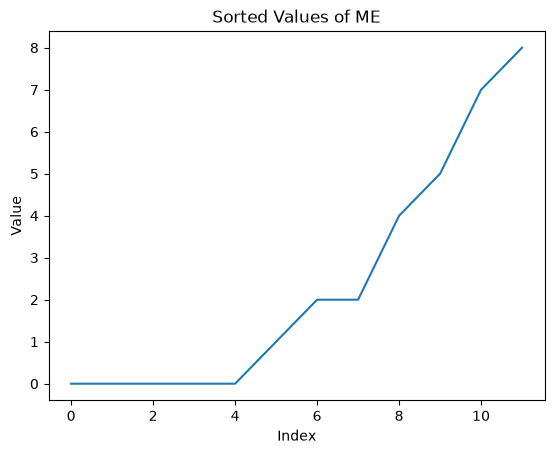

In [23]:
# Plot the sorted values
import matplotlib.pyplot as plt

plt.plot(sorted_ME)
plt.title("Sorted Values of ME")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

# 2. Basic Image Manipulations (40 points)

In [24]:
# (a) Read in the images, image1.jpg and image2.jpg,
# as color images using io.imread from the skimage package.
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import io

image1 = io.imread("data/image1.jpg")
image2 = io.imread("data/image2.jpg")
image1.shape, image2.shape, type(image1), type(image2)

((710, 950, 4), (710, 950, 4), numpy.ndarray, numpy.ndarray)

In [25]:
# (b) Convert the images to double precision and
# rescale them to stretch from minimum value 0 to maximum value 1.
image1 = image1.astype(np.float64)
image2 = image2.astype(np.float64)
img1_min, img1_max = image1.min(), image1.max()
img2_min, img2_max = image2.min(), image2.max()
image1 = (image1 - img1_min) / (img1_max - img1_min)
image2 = (image2 - img2_min) / (img2_max - img2_min)
image1.min(), image1.max(), image2.min(), image2.max()

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

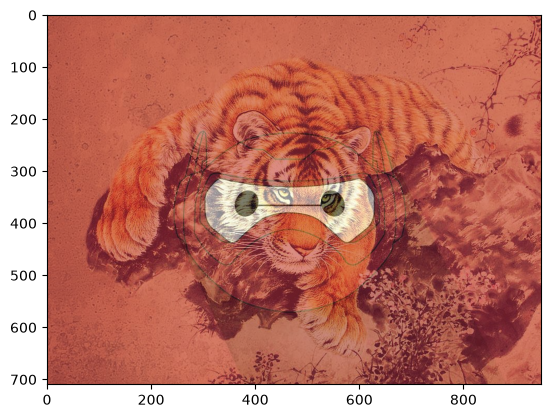

In [26]:
# (c) Add the images together and re-normalize them
# to have minimum value 0 and maximum value 1.
# Save and include this image in your report.
image_sum = image1 + image2
image_sum = image_sum.astype(np.float64)
img_sum_min, img_sum_max = image_sum.min(), image_sum.max()
image_sum = (image_sum - img_sum_min) / (img_sum_max - img_sum_min)
image_sum.min(), image_sum.max()
plt.imsave("data/image_sum.jpg", image_sum)
plt.imshow(image_sum)

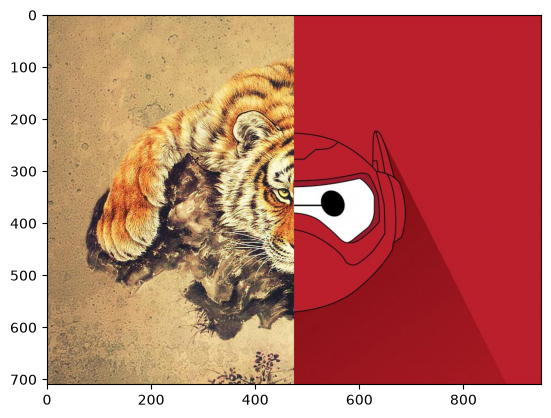

In [27]:
# (d) Create a new image such that the left half of the image
# is the left half of image1 and the right half of the image
# is the right half of image2.
# Save and include this image in your report.
img1_h, img1_w = image1.shape[:2]
img2_h, img2_w = image2.shape[:2]
img1_left = image1[:, : img1_w // 2, :]
img2_right = image2[:, img2_w // 2 :, :]
img_combined = np.concatenate((img1_left, img2_right), axis=1)
plt.imsave("data/image_combined.jpg", img_combined)
plt.imshow(img_combined)

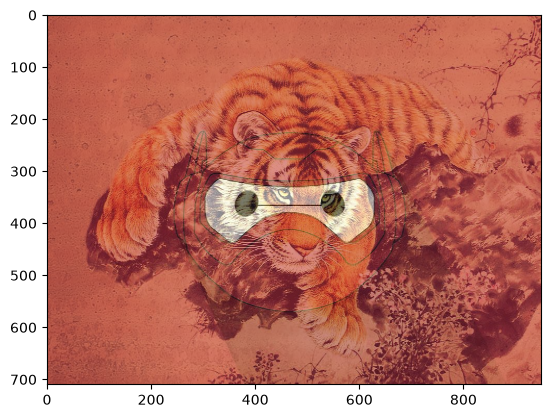

In [28]:
# (e) Using a for loop, create a new image such that every odd numbered
# row is the corresponding row from image1 and the every even row
# is the corresponding row from image2
# (Hint: Re member that indices start at 0 and not 1 in Python).
# Save and include this image in your report.
img_old_even = np.zeros_like(image1)
for i in range(img1_h):
    if i % 2 == 1:
        img_old_even[i] = image1[i]
    else:
        img_old_even[i] = image2[i]
plt.imsave("data/image_old_even.jpg", img_old_even)
plt.imshow(img_old_even)

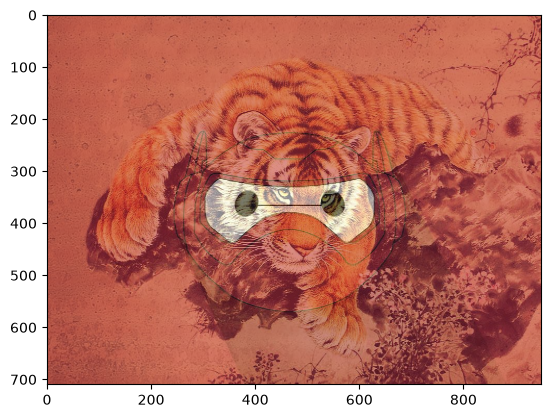

In [29]:
# (f) Accomplish the same task as part e without using a for-loop
# (the functions reshape and tile may be helpful here).
# Briefly explain the logic of your code in your written report.

mask_odd = np.array([[[0]], [[1]]])
mask_even = np.array([[[1]], [[0]]])
mask_odd_tiled = np.tile(
    mask_odd, (img1_h // 2, img1_w, 4)
)
mask_even_tiled = np.tile(
    mask_even, (img2_h // 2, img2_w, 4)
)
image1_odd = np.multiply(image1, mask_odd_tiled)
image2_even = np.multiply(image2, mask_even_tiled)
img_old_even_no_loop = image1_odd + image2_even
plt.imsave("data/img_old_even_no_loop.jpg", img_old_even_no_loop)
plt.imshow(img_old_even_no_loop)

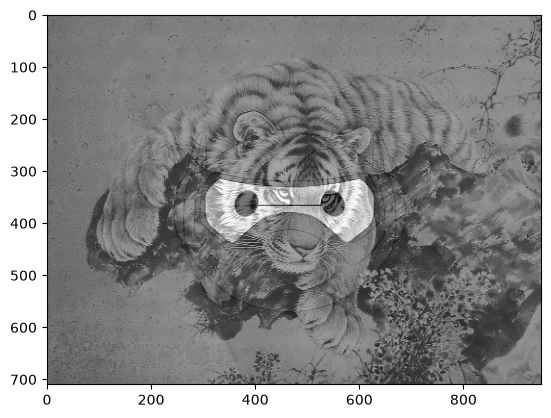

In [30]:
# (g) Convert the result from part f to a grayscale image. 
# Save and include the grayscale image in your report.

# Extract RGB channels (drop the Alpha channel at index 3)
img_old_even_no_loop_rgb = img_old_even_no_loop[:, :, :3]
# Standard luminance weights for Red, Green, and Blue
weights = np.array([0.2989, 0.5870, 0.1140])
img_old_even_no_loop_gray = np.dot(img_old_even_no_loop_rgb, weights)
plt.imshow(img_old_even_no_loop_gray, cmap='gray')
plt.imsave("data/img_old_even_no_loop_gray.jpg", img_old_even_no_loop_gray,  cmap='gray')

# 3. Singular Value Decomposition (40 points)

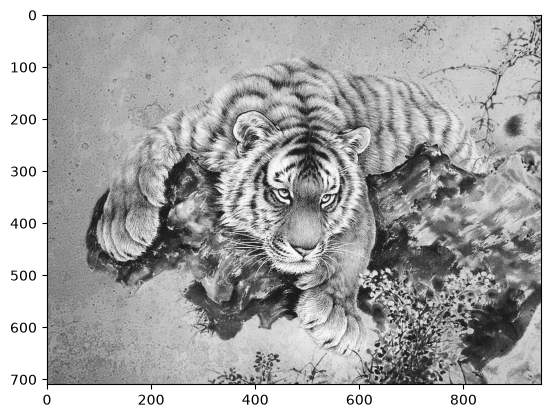

In [4]:
# (a) After reading in image1 as a grayscale image (this is done for you 
# in the code already) take the singular value decomposition of the image.
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import io

image1 = io.imread("data/image1.jpg", as_gray=True)
plt.imshow(image1, cmap="gray")

In [ ]:
# (b) Recall from the discussion section that the best rank n approximation ...
# Save and include the best rank 1 approximation of the (grayscale) image1 in your report.


In [ ]:
# (c) Save and include the best rank 20 approximation of the 
# (grayscale) image1 in your report.